# ${}^{4}{\rm He}$

The interaction is defined in `helium4.py`. It is nonlocal, and so is the counterterm. We will use it to tune the scattering length, $a_0$, **and** the effective range, $r_0$, over a range of short-distance cutoffs, $R$.

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import scienceplots

import helium4plusplus as he4
import lm2m2

plt.style.use('science')
gr = 4/3
h = 3

In [2]:
# angular momentum
ELL = 0

# load lo coupling constants
Rs, c_00s = np.loadtxt('datfiles/rg_flows/nonlocal_lo.txt', unpack=True)
# number of short distance cutoffs
nR = Rs.size

In [3]:
# momentum grid
momenta = np.linspace(0.01/he4.BETA6, 0.3/he4.BETA6, 30)

# scale to render g dimensionless
X = he4.FACTOR * he4.BETA6 # K•Å^3

# kcotd delta returned from a and r
KCD = -1/he4.A0 + he4.R0/2*momenta**2
lm2m2_phase_shifts = np.loadtxt('datfiles/lm2m2_swave_phase_shifts.txt')
lm2m2_momenta = lm2m2_phase_shifts[:, 0]
lm2m2_kcd = lm2m2_momenta / np.tan(lm2m2_phase_shifts[:, 1])

# First, we will tune k(cot(delta)). Then we'll go back and refine a_0 and r_0.
def kcd_diff(c_2s, sys, c_00):
    kcd = sys.kcotd_gen_pert1b_fast(momenta, c_00, *c_2s)
    return np.sum(((KCD - kcd)/KCD)**2)

In [4]:
R=Rs[0]
s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6)

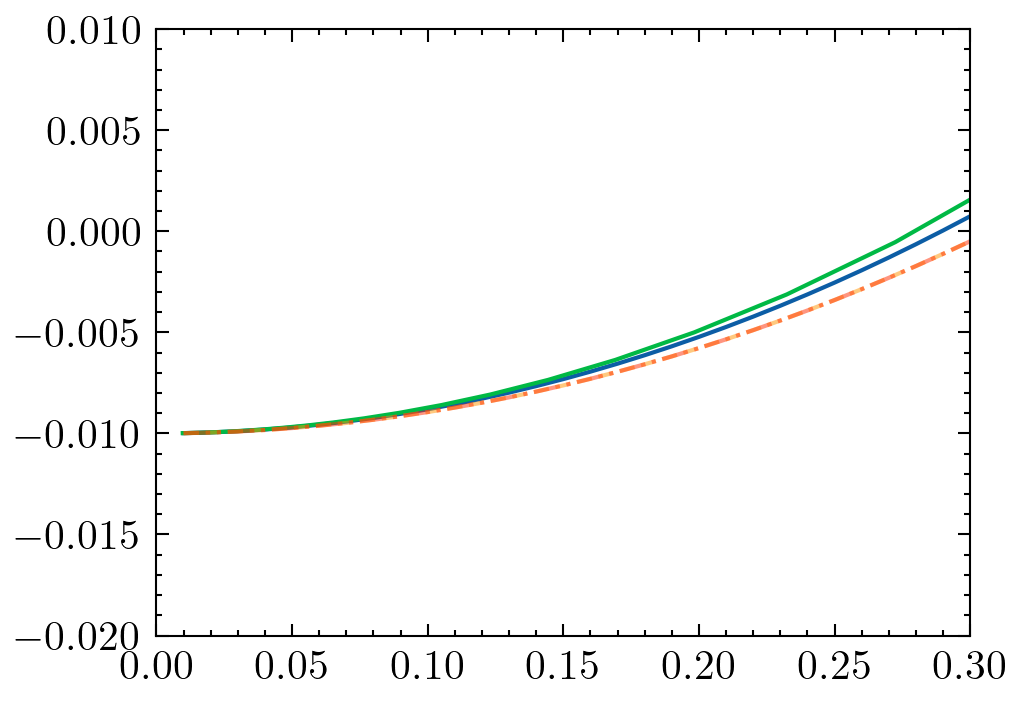

In [5]:
index = 0

fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(momenta*he4.BETA6, KCD)
ax.plot(lm2m2_momenta*lm2m2.BETA6, lm2m2_kcd)
ax.plot(momenta*he4.BETA6, s.kcotd_gen_pert1b_fast(momenta, c_00s[index], 0, 0), linestyle='--', alpha=0.5)
ax.plot(momenta*he4.BETA6, s.kcotd_gen_pert1_fast(momenta, c_00s[index], 0), linestyle='-.', alpha=0.5)

ax.set_xlim([0, 0.3])
ax.set_ylim([-0.02, 0.01]);

In [6]:
from scipy.optimize import minimize

In [7]:
result = minimize(lambda x: kcd_diff(x, s, c_00s[index]), [-1, 1])

In [8]:
result

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0001723205871824945
        x: [-5.378e+00  3.568e+01]
      nit: 12
      jac: [-2.474e-06 -3.734e-07]
 hess_inv: [[ 4.415e+01 -2.848e+02]
            [-2.848e+02  1.837e+03]]
     nfev: 48
     njev: 16

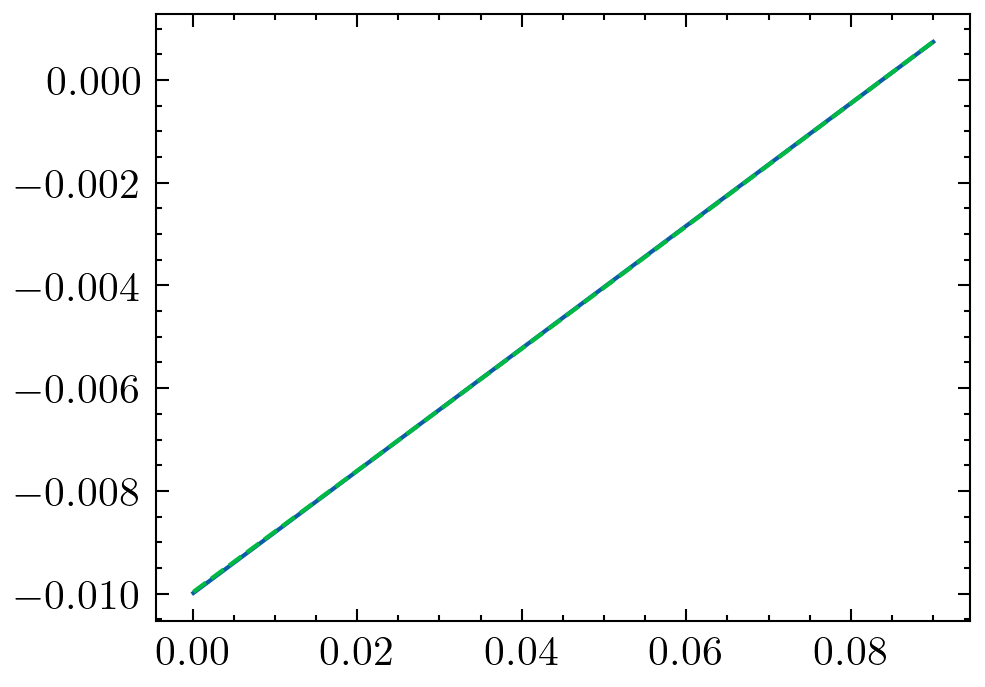

In [9]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot((momenta*he4.BETA6)**2, KCD)
ax.plot((momenta*he4.BETA6)**2, s.kcotd_gen_pert1b_fast(momenta, c_00s[index], *result.x), linestyle='--');

In [10]:
s.a0_and_r0_pert1b_fast(c_00s[index], *result.x, momenta, return_sigma=True)

(100.2425960098853,
 7.2213313544846685,
 array([4.21019429e-07, 1.38015862e-03, 2.62822967e-02]))

In [11]:
def par_diff(c_2s, sys, c_00):
    a0, r0 = sys.a0_and_r0_pert1b_fast(c_00, *c_2s, momenta)
    return he4.A0*(1/he4.A0 - 1/a0), (he4.R0 - r0)/he4.R0

In [12]:
from scipy.optimize import fsolve

In [13]:
result1 = fsolve(lambda x: par_diff(x, s, c_00s[index]), result.x)

In [15]:
result1

array([-6.1706484 , 40.91293957])

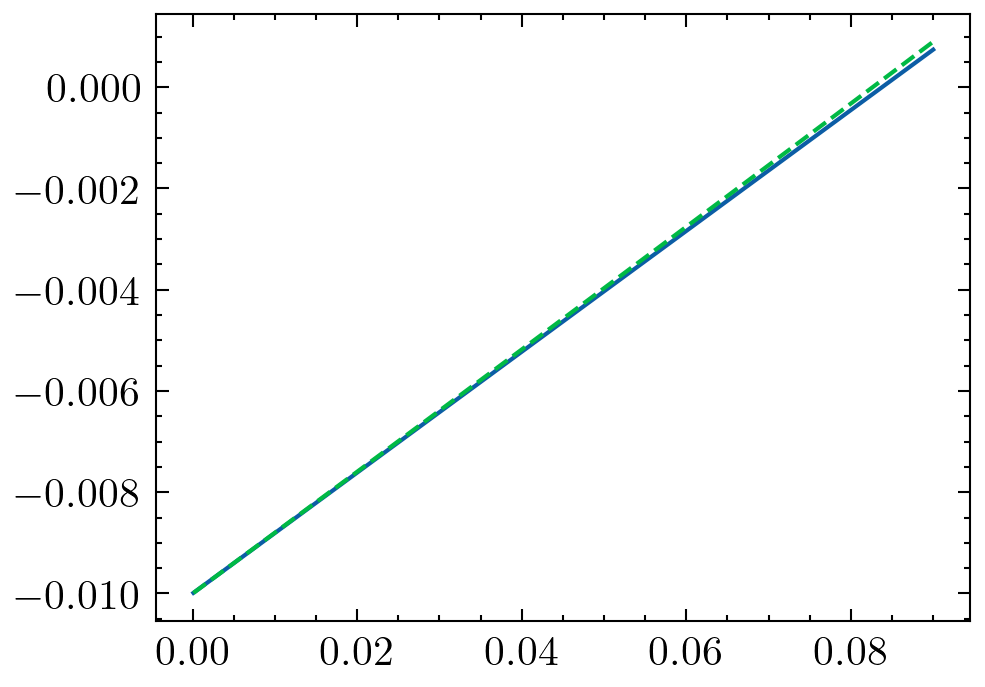

In [16]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot((momenta*he4.BETA6)**2, KCD)
ax.plot((momenta*he4.BETA6)**2, s.kcotd_gen_pert1b_fast(momenta, c_00s[index], *result1), linestyle='--');

In [18]:
s.a0_and_r0_pert1b_fast(c_00s[index], *result1, momenta, return_sigma=True)

(100.00000000069052,
 7.329999999381278,
 array([4.72447240e-07, 1.54874619e-03, 2.94927064e-02]))

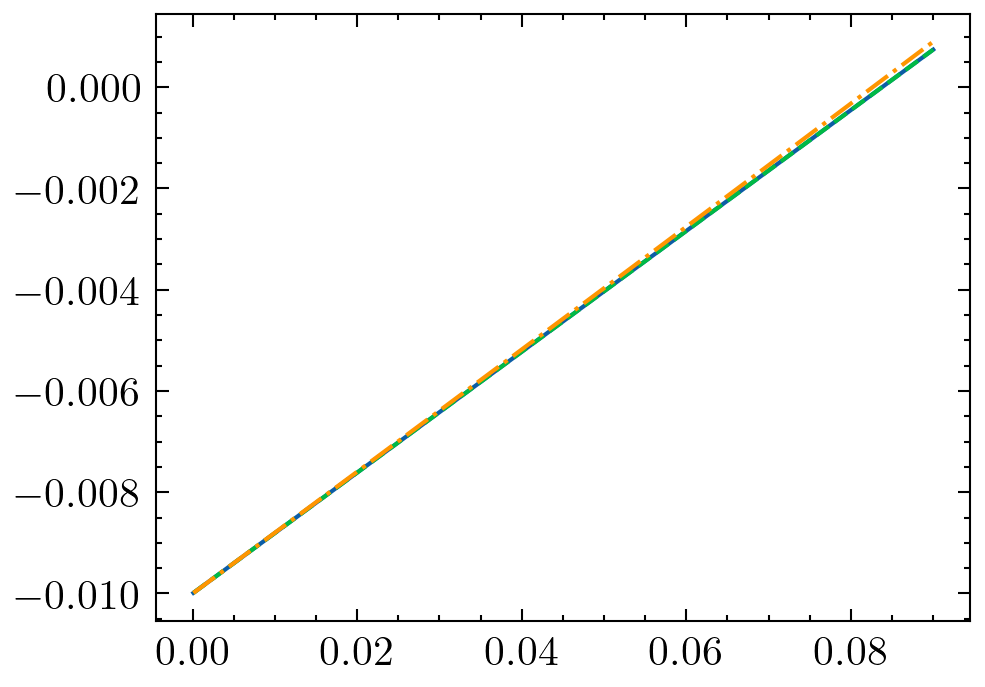

In [19]:
a0, r0 = s.a0_and_r0_pert1b_fast(c_00s[index], *result1, momenta)

fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot((momenta*he4.BETA6)**2, KCD)
ax.plot((momenta*he4.BETA6)**2, -1/a0 + r0/2*momenta**2, linestyle='--')
ax.plot((momenta*he4.BETA6)**2, s.kcotd_gen_pert1b_fast(momenta, c_00s[index], *result1), linestyle='-.');